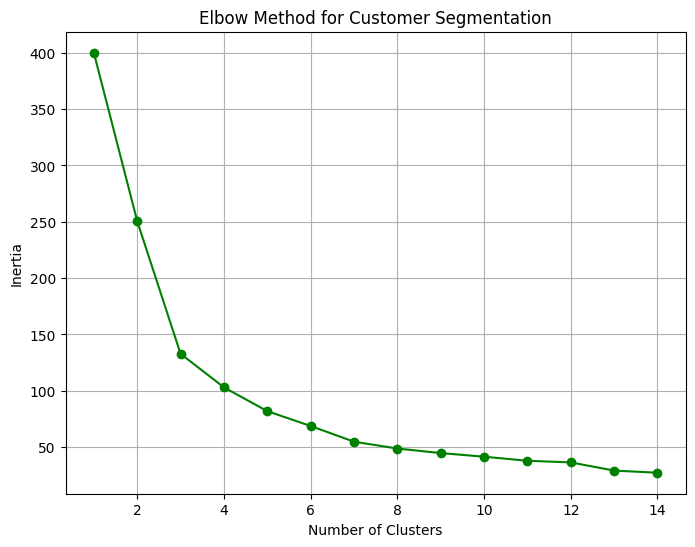

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       1   19                  15                      39   
1           2       1   21                  15                      81   
2           3       0   20                  16                       6   
3           4       0   23                  16                      77   
4           5       0   31                  17                      40   

   cluster  
0        2  
1        2  
2        2  
3        2  
4        2  


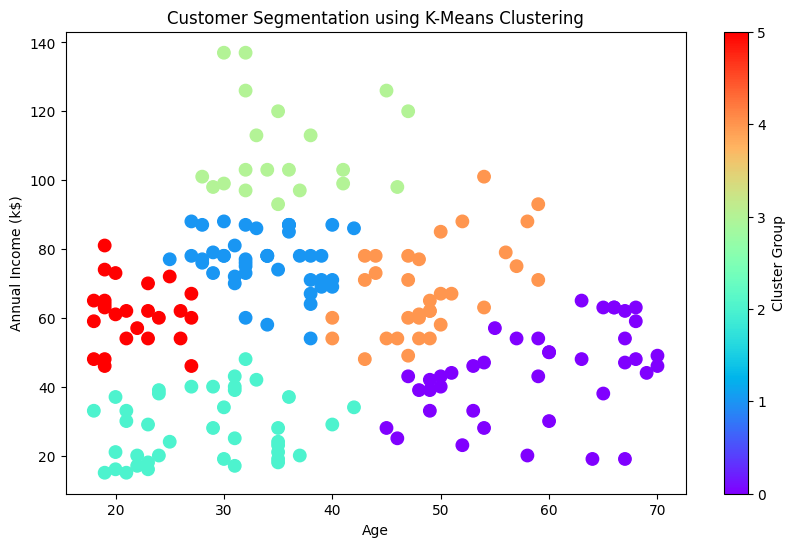

Cluster file saved successfully.


C:\Users\medip\AppData\Local\Temp\ipykernel_38816\2894491971.py:95: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submission.rename(


In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('mall_customers.csv')

# Convert Gender column into numeric values
label_encoder = LabelEncoder()

data['Gender'] = label_encoder.fit_transform(data['Gender'])

# Select features
features = data[['Age', 'Annual Income (k$)']]

# Scale features
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

# Elbow Method
inertia = []

for k in range(1, 15):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

# Plot elbow graph
plt.figure(figsize=(8, 6))

plt.plot(
    range(1, 15),
    inertia,
    marker='o',
    color='green'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.title('Elbow Method for Customer Segmentation')

plt.grid(True)

plt.savefig('elbow_method.png')

plt.show()

# Apply KMeans
k = 6

kmeans = KMeans(
    n_clusters=k,
    random_state=42
)

data['cluster'] = kmeans.fit_predict(scaled_features)

# Print output
print(data.head())

# Cluster Visualization
plt.figure(figsize=(10, 6))

plt.scatter(
    data['Age'],
    data['Annual Income (k$)'],
    c=data['cluster'],
    cmap='rainbow',
    s=80
)

plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')

plt.title('Customer Segmentation using K-Means Clustering')

plt.colorbar(label='Cluster Group')

plt.savefig('customer_clusters.png')

plt.show()

# Save cluster results
submission = data[['CustomerID', 'cluster']]

submission.rename(
    columns={
        'CustomerID': 'Customer_ID',
        'cluster': 'Cluster_Label'
    },
    inplace=True
)

submission.to_csv(
    'customer_clusters.csv',
    index=False
)

print("Cluster file saved successfully.")